# SugarSense — Early Diabetes Risk Screening with Supervised Machine Learning

## Project Overview

SugarSense is a supervised machine learning project for early diabetes risk screening.

The project uses clinical measurements to predict whether a person is likely to have diabetes.

The main goal is to reduce false negatives because missing a potentially diabetic patient is more concerning in a screening system than generating an additional referral.

### Dataset

The project uses the Pima Indians Diabetes Database.

The target variable is:

- `Outcome = 0` → No diabetes
- `Outcome = 1` → Diabetes

### Main Evaluation Metrics

The main metrics used in this project are:

- ROC-AUC
- Recall

Additional metrics include:

- Accuracy
- Precision
- F1-score

The test set is kept separate and is used only for the final evaluation.

## Project Objective

The objectives of this project are:

1. Audit and clean the diabetes dataset.
2. Explore relationships between clinical features and diabetes.
3. Create useful row-wise interaction features.
4. Build leakage-free preprocessing and machine learning pipelines.
5. Compare six supervised machine learning models.
6. Tune at least three models using RandomizedSearchCV.
7. Select the final model using cross-validation performance.
8. Evaluate the selected model once on the untouched test set.
9. Tune the classification threshold to achieve high recall.
10. Identify the most important features affecting the model predictions.

This project is intended for educational screening support and is not a medical diagnosis system.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\Koneti sai charanya\OneDrive\Desktop\SugarSense\diabetes_screening_data.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

# Phase 1 — Data Audit and Quality Check

In this phase, we inspect the dataset structure, data types, descriptive statistics, duplicates, class balance, and problematic values.

The goal is to understand the quality of the data before building machine learning models.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome Class Balance")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

<Figure size 600x400 with 1 Axes>

## Checking Physiologically Implausible Zero Values

Some clinical measurements should not normally be zero for a living patient.

Therefore, zero values in the following columns are treated as potentially missing or invalid measurements:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

These values will later be converted to missing values and handled inside the machine learning preprocessing pipeline.

This prevents data leakage because the imputation values will be learned only from the training data.

In [12]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_counts = (df[zero_columns] == 0).sum()

zero_percent = (df[zero_columns] == 0).mean() * 100

problematic_values = pd.DataFrame({
    "Zero Count": zero_counts,
    "Percentage": zero_percent
})

problematic_values

,Zero Count,Percentage
Glucose,5,0.651042
BloodPressure,35,4.557292
SkinThickness,227,29.557292
Insulin,374,48.697917
BMI,11,1.432292


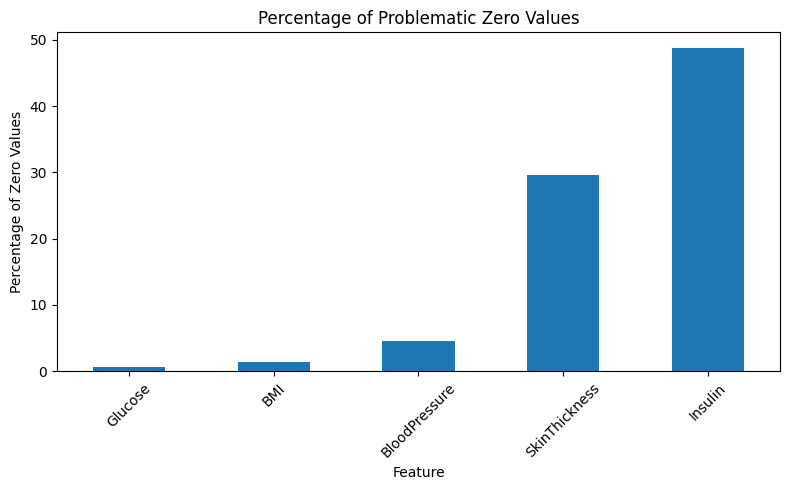

In [13]:
plt.figure(figsize=(8, 5))

problematic_values["Percentage"].sort_values().plot(kind="bar")

plt.title("Percentage of Problematic Zero Values")
plt.xlabel("Feature")
plt.ylabel("Percentage of Zero Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Phase 1 — Key Observations

- The dataset contains 768 patient records and 9 columns.
- The target variable is `Outcome`.
- The dataset contains two classes: diabetic and non-diabetic.
- Some clinical variables contain zero values that are physiologically questionable.
- These problematic zero values will be treated as missing values during preprocessing.
- Missing-value handling will be performed inside the machine learning pipelines to avoid data leakage.

# Phase 2 — Exploratory Data Analysis

In this phase, we explore the distributions of the clinical features and their relationship with diabetes outcome.

We will use:

- Mean comparisons
- Histograms
- Boxplots
- Correlation analysis
- Correlation heatmap

The goal is to identify potentially useful and weak features before modeling.

In [14]:
feature_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

In [15]:
non_diabetic = df[df["Outcome"] == 0]
diabetic = df[df["Outcome"] == 1]

print("Non-diabetic patients:", len(non_diabetic))
print("Diabetic patients:", len(diabetic))

Non-diabetic patients: 500
Diabetic patients: 268


In [16]:
comparison = df.groupby("Outcome")[feature_columns].mean().T

comparison

Outcome,0,1
Pregnancies,3.298000,4.865672
Glucose,109.980000,141.257463
BloodPressure,68.184000,70.824627
SkinThickness,19.664000,22.164179
Insulin,68.792000,100.335821
BMI,30.304200,35.142537
DiabetesPedigreeFunction,0.429734,0.550500
Age,31.190000,37.067164


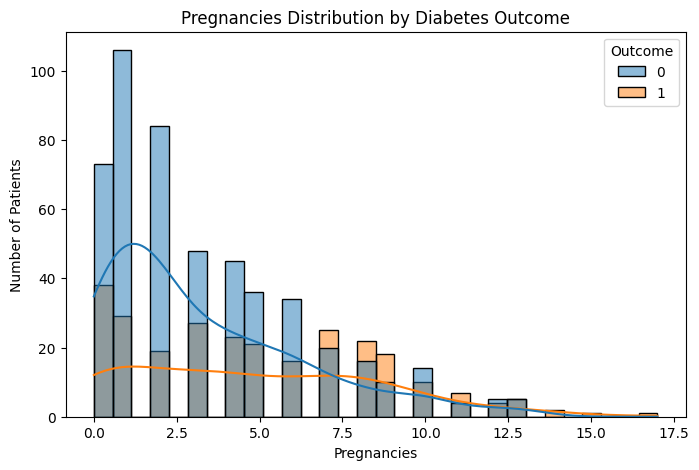

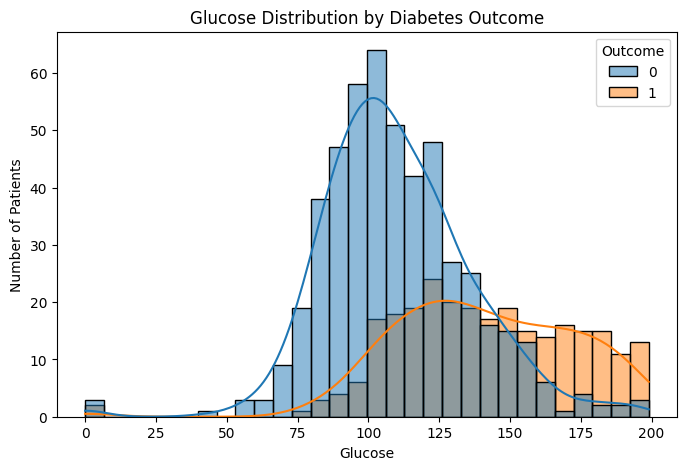

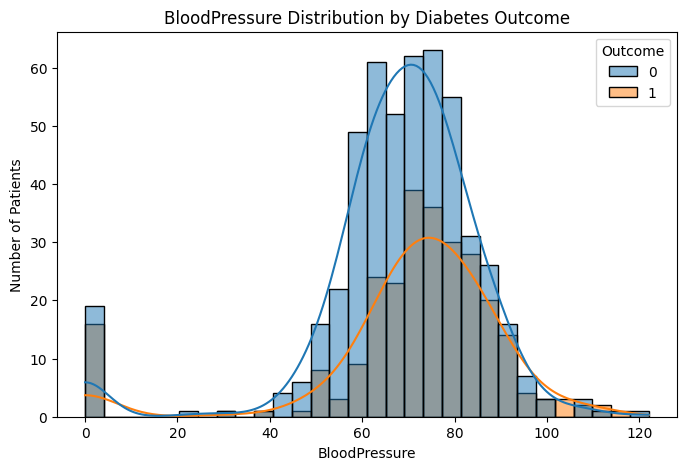

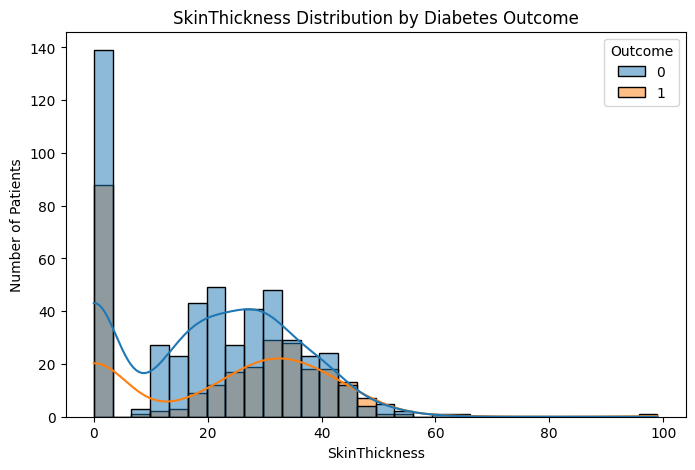

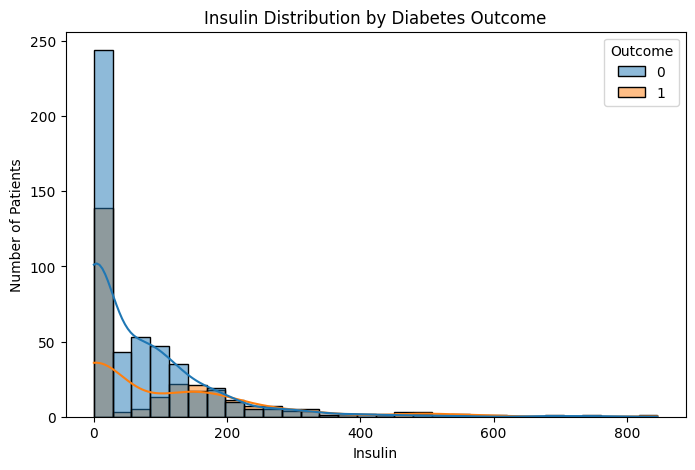

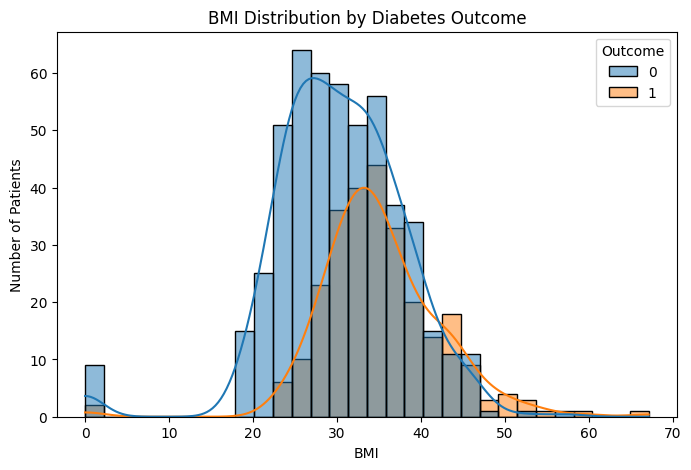

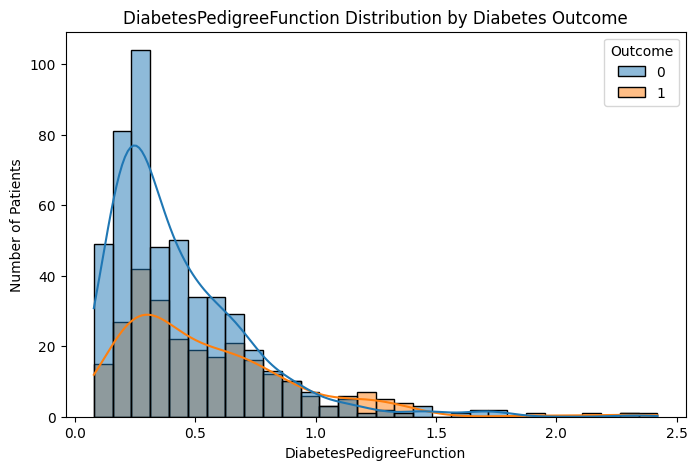

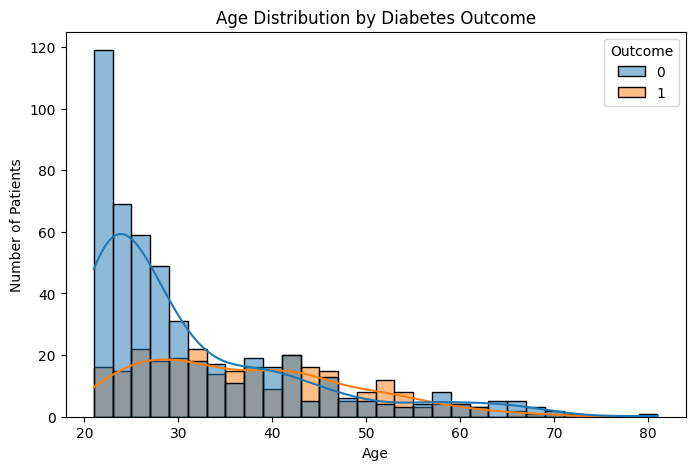

In [17]:
for feature in feature_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Outcome",
        kde=True,
        bins=30
    )

    plt.title(f"{feature} Distribution by Diabetes Outcome")
    plt.xlabel(feature)
    plt.ylabel("Number of Patients")

    plt.show()

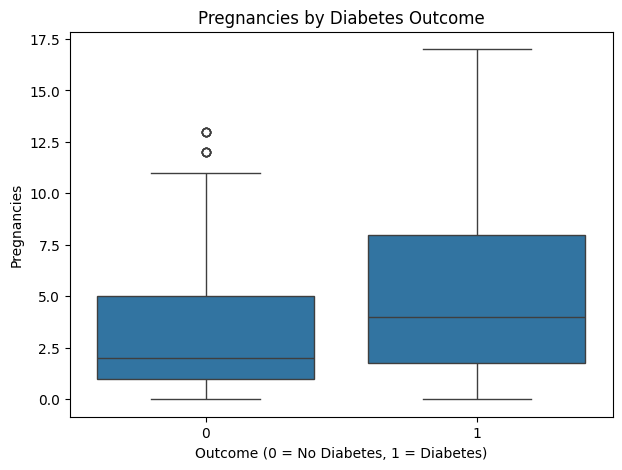

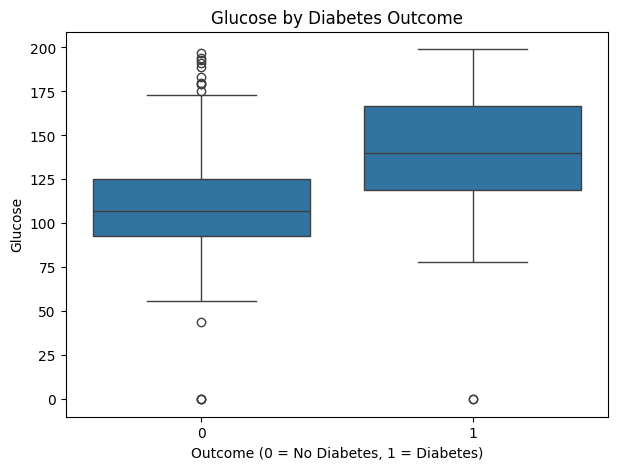

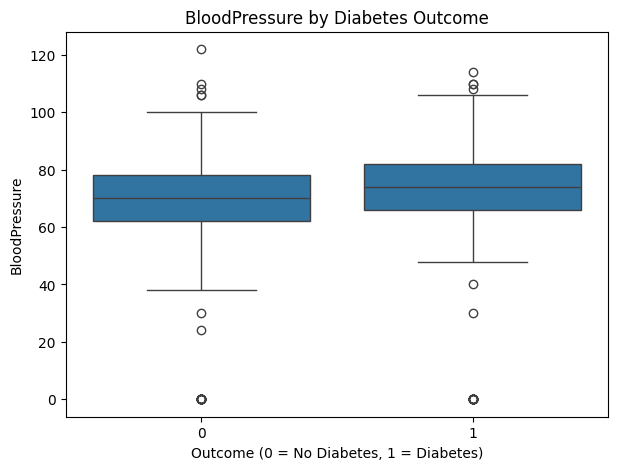

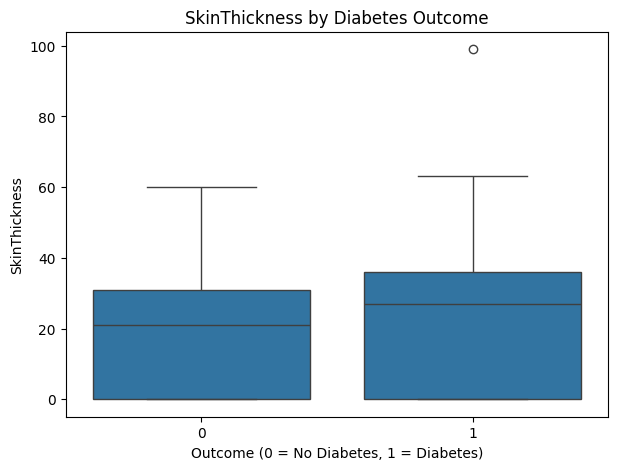

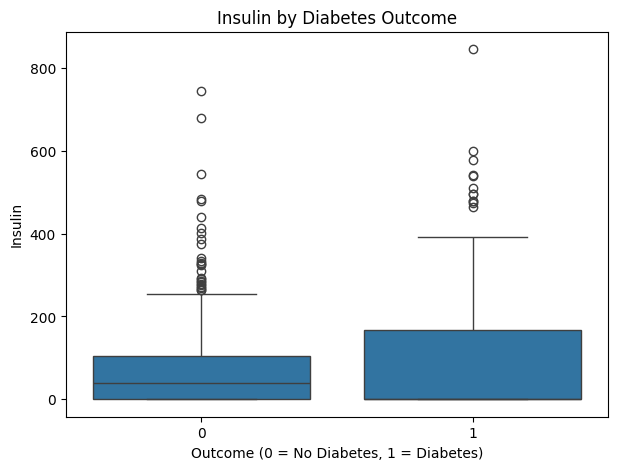

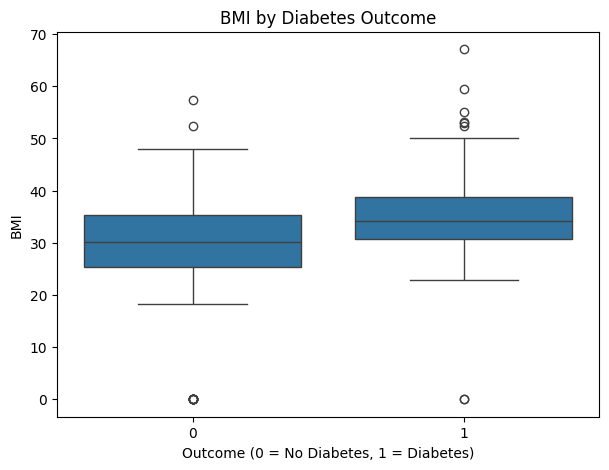

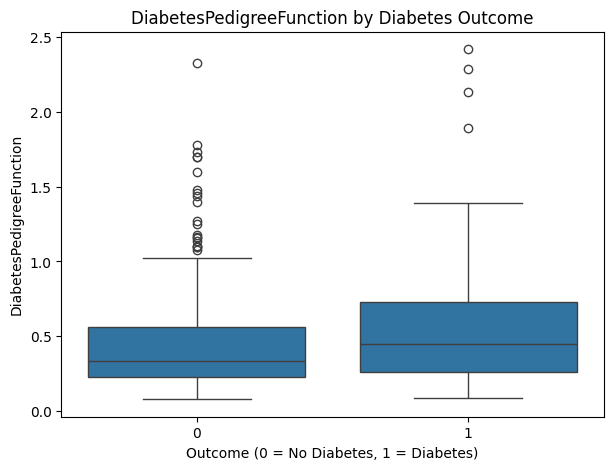

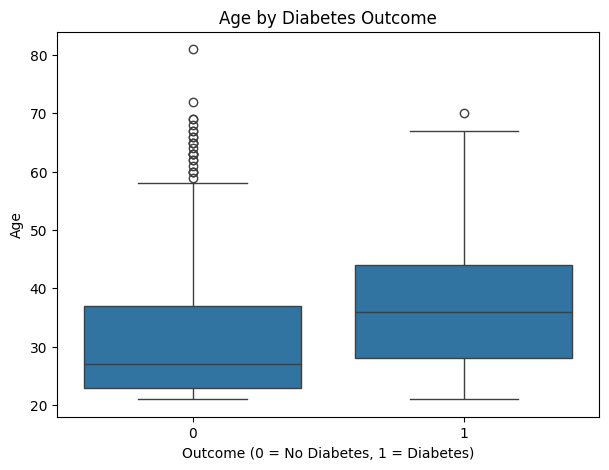

In [18]:
for feature in feature_columns:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Outcome",
        y=feature
    )

    plt.title(f"{feature} by Diabetes Outcome")
    plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
    plt.ylabel(feature)

    plt.show()

In [19]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


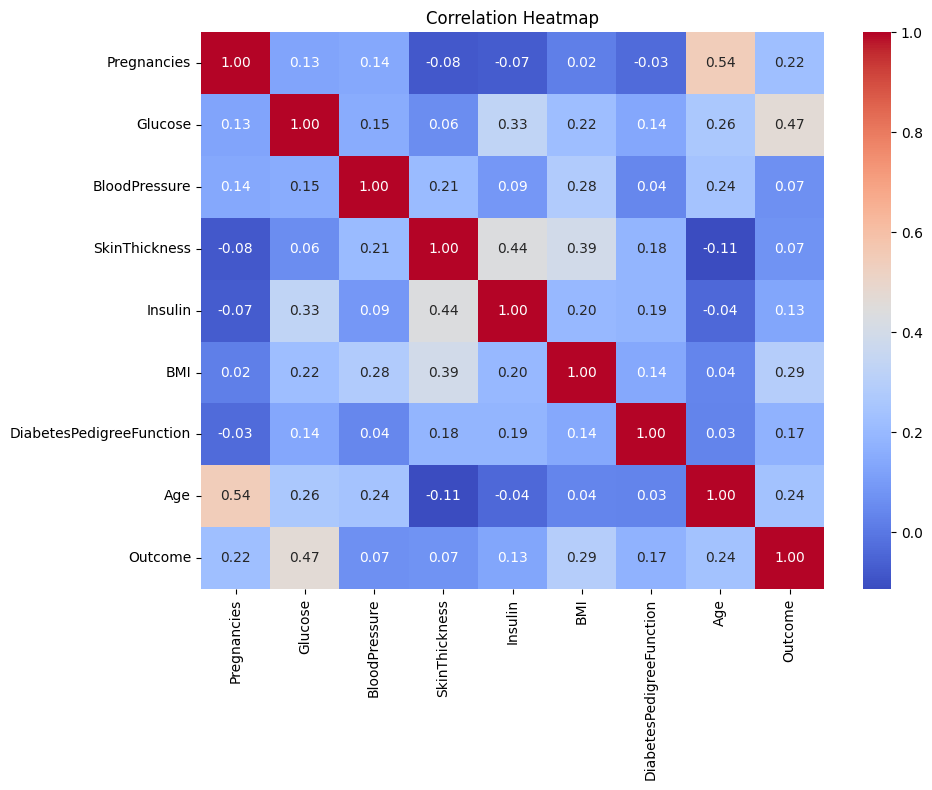

In [20]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [21]:
outcome_correlation = (
    correlation_matrix["Outcome"]
    .drop("Outcome")
    .sort_values(key=abs, ascending=False)
)

outcome_correlation

Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

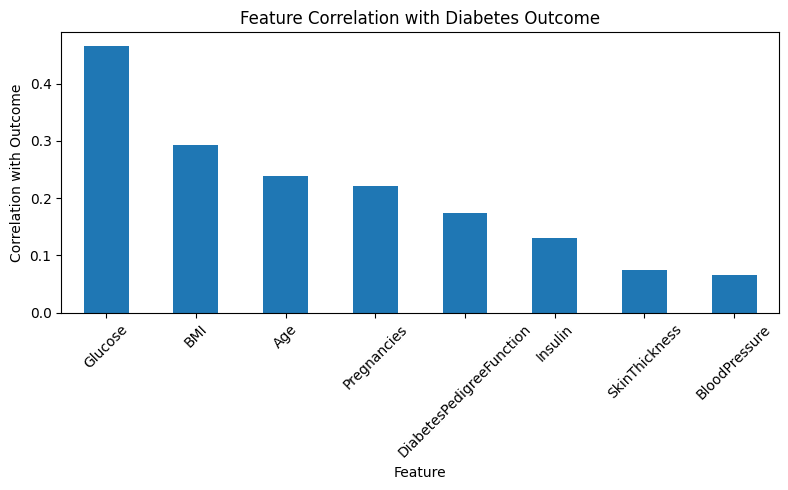

In [22]:
plt.figure(figsize=(8, 5))

outcome_correlation.plot(kind="bar")

plt.title("Feature Correlation with Diabetes Outcome")
plt.xlabel("Feature")
plt.ylabel("Correlation with Outcome")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Phase 2 — Key Observations

Based on the exploratory analysis:

1. Glucose shows one of the strongest relationships with diabetes outcome.
2. BMI also shows a useful relationship with diabetes risk.
3. Age and Pregnancies show some relationship with the target.
4. DiabetesPedigreeFunction provides additional information about diabetes risk.
5. BloodPressure, SkinThickness, and Insulin show weaker direct linear correlations with the outcome.
6. A weak correlation does not necessarily mean that a feature is useless because machine learning models can capture non-linear relationships and interactions.

# Phase 3 — Feature Engineering

Feature engineering is used to create additional information from the existing clinical measurements.

Three row-wise interaction features will be created:

- Glucose × BMI
- Glucose × Age
- BMI × Age

These features allow the models to capture possible interactions between important clinical measurements.

No dataset-wide mean or median is calculated here.

Missing-value handling will remain inside the machine learning pipeline.

In [23]:
model_df = df.copy()

In [24]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

model_df[zero_columns] = model_df[zero_columns].replace(0, np.nan)

In [25]:
model_df["Glucose_BMI"] = (
    model_df["Glucose"] * model_df["BMI"]
)

model_df["Glucose_Age"] = (
    model_df["Glucose"] * model_df["Age"]
)

model_df["BMI_Age"] = (
    model_df["BMI"] * model_df["Age"]
)

In [26]:
model_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI,Glucose_Age,BMI_Age
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,4972.8,7400.0,1680.0
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,2261.0,2635.0,824.6
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,4263.9,5856.0,745.6
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2500.9,1869.0,590.1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5904.7,4521.0,1422.3


In [27]:
model_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_BMI',
       'Glucose_Age', 'BMI_Age'],
      dtype='str')

In [28]:
model_df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
Glucose_BMI                  16
Glucose_Age                   5
BMI_Age                      11
dtype: int64

## Phase 3 — Feature Engineering Summary

Three row-wise interaction features were added:

- `Glucose_BMI`
- `Glucose_Age`
- `BMI_Age`

The original clinical variables containing problematic zero values were converted to missing values.

No imputation was performed manually. Imputation will be learned only from the training data through the machine learning pipelines.

# Phase 4 — Train/Test Split and Machine Learning Pipelines

The dataset is divided into:

- 80% training data
- 20% testing data

The split is stratified so that the proportion of diabetic and non-diabetic patients is approximately maintained.

The test set will remain untouched until the final evaluation.

All preprocessing steps are placed inside pipelines to prevent data leakage.

In [29]:
X = model_df.drop("Outcome", axis=1)
y = model_df["Outcome"]

In [30]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 11)
y shape: (768,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 614
Testing rows: 154


In [33]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [34]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class:", negative_count)
print("Positive class:", positive_count)
print("Scale positive weight:", round(scale_pos_weight, 3))

Negative class: 400
Positive class: 214
Scale positive weight: 1.869


In [35]:
scaled_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Why Scaling?

Scaling puts numerical features on a similar scale.

Scaling is important for:

- Logistic Regression
- KNN
- SVM

Median imputation is also performed inside this pipeline.

In [36]:
tree_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

Tree-based models do not require feature scaling.

However, they still need missing values to be handled, so median imputation is included inside the pipeline.

In [37]:
logistic_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [38]:
knn_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [39]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        )
    )
])

In [40]:
random_forest_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=1
        )
    )
])

In [41]:
xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1
        )
    )
])

In [42]:
svm_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    (
        "model",
        SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [43]:
models = {
    "Logistic Regression": logistic_pipeline,
    "KNN": knn_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgb_pipeline,
    "SVM": svm_pipeline
}

## Models Used

Six supervised learning models will be compared:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. XGBoost
6. Support Vector Machine

The models will be compared using 5-fold stratified cross-validation.

# Phase 5 — Comparing Six Machine Learning Models

All six models are evaluated using 5-fold Stratified Cross-Validation on the training data.

The evaluation metrics are:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- ROC-AUC standard deviation
- Training ROC-AUC
- Overfit gap

ROC-AUC and Recall are especially important because this is a screening problem where false negatives are costly.

In [44]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [45]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std(),
        "Train ROC-AUC Mean": scores["train_roc_auc"].mean(),
        "Overfit Gap": (
            scores["train_roc_auc"].mean()
            - scores["test_roc_auc"].mean()
        )
    })

In [46]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "ROC-AUC Mean",
    ascending=False
)

cv_results_df

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,ROC-AUC Std,Train ROC-AUC Mean,Overfit Gap
0,Logistic Regression,0.758963,0.640861,0.705759,0.670500,0.843135,0.017996,0.853589,0.010453
5,SVM,0.776796,0.654308,0.794352,0.714502,0.837753,0.032662,0.902916,0.065162
3,Random Forest,0.763814,0.654176,0.691584,0.671593,0.822967,0.032285,1.000000,0.177033
4,XGBoost,0.745888,0.620988,0.705205,0.658967,0.811121,0.039461,0.997143,0.186021
1,KNN,0.752379,0.673122,0.588926,0.624690,0.796106,0.047115,0.909035,0.112929
2,Decision Tree,0.682447,0.551066,0.542082,0.544864,0.649791,0.036425,1.000000,0.350209


## Phase 5 — Model Comparison Observation

The models are ranked using cross-validation ROC-AUC.

The test set is not used for model selection.

A model with high ROC-AUC and strong recall is preferred because the project's main goal is reliable diabetes risk screening.

# Phase 6 — Hyperparameter Tuning

Three models will be tuned using RandomizedSearchCV:

- Logistic Regression
- Random Forest
- XGBoost

ROC-AUC is used as the optimization metric.

The test set remains untouched during tuning.

In [47]:
logistic_params = {
    "model__C": np.logspace(-2, 2, 10),
    "model__solver": [
        "liblinear",
        "lbfgs"
    ]
}

In [48]:
random_forest_params = {
    "model__n_estimators": [
        100, 200, 300, 500
    ],
    "model__max_depth": [
        None, 3, 5, 7, 10
    ],
    "model__min_samples_split": [
        2, 5, 10
    ],
    "model__min_samples_leaf": [
        1, 2, 4
    ],
    "model__max_features": [
        "sqrt",
        "log2",
        None
    ]
}

In [49]:
xgb_params = {
    "model__n_estimators": [
        100, 200, 300, 500
    ],
    "model__max_depth": [
        2, 3, 4, 5
    ],
    "model__learning_rate": [
        0.01, 0.03, 0.05, 0.1
    ],
    "model__subsample": [
        0.7, 0.8, 1.0
    ],
    "model__colsample_bytree": [
        0.7, 0.8, 1.0
    ],
    "model__min_child_weight": [
        1, 3, 5
    ]
}

In [50]:
searches = {
    "Tuned Logistic Regression": RandomizedSearchCV(
        estimator=logistic_pipeline,
        param_distributions=logistic_params,
        n_iter=10,
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    ),

    "Tuned Random Forest": RandomizedSearchCV(
        estimator=random_forest_pipeline,
        param_distributions=random_forest_params,
        n_iter=10,
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    ),

    "Tuned XGBoost": RandomizedSearchCV(
        estimator=xgb_pipeline,
        param_distributions=xgb_params,
        n_iter=10,
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    )
}

In [51]:
for name, search in searches.items():

    print("Running:", name)

    search.fit(X_train, y_train)

    print(
        "Best ROC-AUC:",
        round(search.best_score_, 4)
    )

    print("Best Parameters:")
    print(search.best_params_)

    print("-" * 60)

Running: Tuned Logistic Regression
Best ROC-AUC: 0.8455
Best Parameters:
{'model__solver': 'lbfgs', 'model__C': np.float64(0.027825594022071243)}
------------------------------------------------------------
Running: Tuned Random Forest
Best ROC-AUC: 0.838
Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 5}
------------------------------------------------------------
Running: Tuned XGBoost
Best ROC-AUC: 0.8301
Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
------------------------------------------------------------


In [52]:
tuned_models = {
    "Tuned Logistic Regression":
        searches["Tuned Logistic Regression"].best_estimator_,

    "Tuned Random Forest":
        searches["Tuned Random Forest"].best_estimator_,

    "Tuned XGBoost":
        searches["Tuned XGBoost"].best_estimator_
}

In [53]:
tuning_results = []

for name, search in searches.items():

    tuning_results.append({
        "Model": name,
        "Best ROC-AUC": search.best_score_
    })

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df

,Model,Best ROC-AUC
0,Tuned Logistic Regression,0.845520
1,Tuned Random Forest,0.837955
2,Tuned XGBoost,0.830101


In [54]:
final_candidates = {
    "Tuned Logistic Regression":
        tuned_models["Tuned Logistic Regression"],

    "KNN":
        models["KNN"],

    "Decision Tree":
        models["Decision Tree"],

    "Tuned Random Forest":
        tuned_models["Tuned Random Forest"],

    "Tuned XGBoost":
        tuned_models["Tuned XGBoost"],

    "SVM":
        models["SVM"]
}

In [55]:
final_candidate_results = []

for name, model in final_candidates.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    final_candidate_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

In [56]:
final_candidate_df = pd.DataFrame(
    final_candidate_results
)

final_candidate_df = final_candidate_df.sort_values(
    "ROC-AUC Mean",
    ascending=False
)

final_candidate_df

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,ROC-AUC Std
0,Tuned Logistic Regression,0.760549,0.647334,0.705648,0.672896,0.845520,0.014465
3,Tuned Random Forest,0.765427,0.632714,0.784939,0.700369,0.837955,0.031875
5,SVM,0.776796,0.654308,0.794352,0.714502,0.837753,0.032662
4,Tuned XGBoost,0.747474,0.615612,0.752381,0.676174,0.830101,0.033474
1,KNN,0.752379,0.673122,0.588926,0.624690,0.796106,0.047115
2,Decision Tree,0.682447,0.551066,0.542082,0.544864,0.649791,0.036425


In [57]:
best_row = final_candidate_df.iloc[0]

final_model_name = best_row["Model"]

final_model = final_candidates[final_model_name]

print("Selected final model:", final_model_name)
print("CV ROC-AUC:", round(best_row["ROC-AUC Mean"], 4))

Selected final model: Tuned Logistic Regression
CV ROC-AUC: 0.8455


## Final Model Selection

The final model is selected using cross-validation performance on the training data.

The untouched test set is not used to choose the final model.

The model with the strongest cross-validation ROC-AUC is selected as the final candidate.

# Phase 7 — Final Test Evaluation

The selected model is now trained on the training data and evaluated on the previously untouched test set.

This is the first stage where the test set is used.

The following metrics will be calculated:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

We will also inspect the confusion matrix, ROC curve, and Precision-Recall curve.

In [58]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Pregnancies','Glucose','BloodPressure',...,'Glucose_BMI','Glucose_Age', 'BMI_Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be i

In [59]:
y_test_pred = final_model.predict(X_test)

y_test_prob = final_model.predict_proba(X_test)[:, 1]

In [60]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

In [61]:
print("Final Model:", final_model_name)
print()
print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall   :", round(test_recall, 4))
print("F1 Score :", round(test_f1, 4))
print("ROC-AUC  :", round(test_roc_auc, 4))

Final Model: Tuned Logistic Regression

Accuracy : 0.7208
Precision: 0.5902
Recall   : 0.6667
F1 Score : 0.6261
ROC-AUC  : 0.8074


In [3]:
from sklearn.metrics import classification_report

In [16]:
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.65      0.75       100
           1       0.56      0.83      0.67        54

    accuracy                           0.71       154
   macro avg       0.72      0.74      0.71       154
weighted avg       0.77      0.71      0.72       154



In [62]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

cm

array([[75, 25],
       [18, 36]])

In [63]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 75
False Positives: 25
False Negatives: 18
True Positives : 36


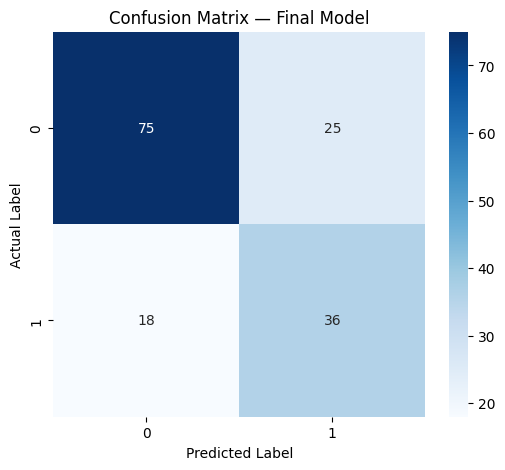

In [64]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix — Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

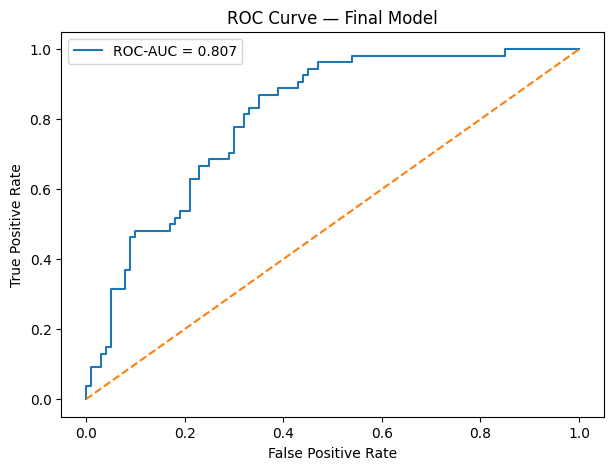

In [65]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {test_roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Final Model")

plt.legend()

plt.show()

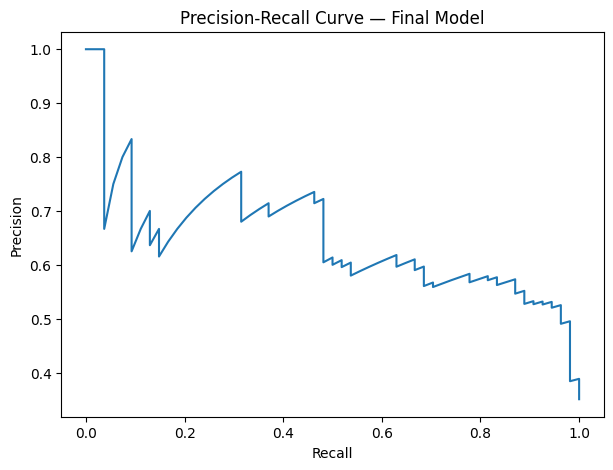

In [66]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve — Final Model")

plt.show()

In [67]:
final_test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})

final_test_results

,Metric,Score
0,Accuracy,0.720779
1,Precision,0.590164
2,Recall,0.666667
3,F1 Score,0.626087
4,ROC-AUC,0.807407


## Phase 7 — Interpretation

The final model is evaluated on the untouched test set.

Recall is particularly important because a false negative represents a potentially diabetic patient being predicted as non-diabetic.

The confusion matrix helps identify the number of:

- False negatives
- False positives
- True positives
- True negatives

The ROC curve shows the model's ability to separate the two classes across different thresholds.

# Phase 8 — Classification Threshold Tuning

Most binary classifiers use a default probability threshold of 0.50.

However, this project prioritizes high recall because missing a potentially diabetic patient is costly.

Therefore, we will use out-of-fold predictions from the training data to select a threshold.

The target is:

Recall >= 85%

Among the thresholds that satisfy this condition, we choose the one with the best possible precision.

The test set is not used to select the threshold.

In [68]:
oof_prob = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [69]:
oof_precision, oof_recall, oof_thresholds = precision_recall_curve(
    y_train,
    oof_prob
)

In [70]:
threshold_table = pd.DataFrame({
    "Threshold": oof_thresholds,
    "Precision": oof_precision[:-1],
    "Recall": oof_recall[:-1]
})

threshold_table.head()

,Threshold,Precision,Recall
0,0.039136,0.348534,1.0
1,0.042368,0.349103,1.0
2,0.046964,0.349673,1.0
3,0.054538,0.350245,1.0
4,0.055458,0.350820,1.0


In [71]:
eligible_thresholds = threshold_table[
    threshold_table["Recall"] >= 0.85
]

In [72]:
if eligible_thresholds.empty:

    print("No threshold achieved Recall >= 85%.")

else:

    best_threshold_row = (
        eligible_thresholds
        .sort_values(
            ["Precision", "Recall"],
            ascending=False
        )
        .iloc[0]
    )

    tuned_threshold = best_threshold_row["Threshold"]

    print(
        "Selected threshold:",
        round(tuned_threshold, 4)
    )

    print(
        "OOF Recall:",
        round(best_threshold_row["Recall"], 4)
    )

    print(
        "OOF Precision:",
        round(best_threshold_row["Precision"], 4)
    )

Selected threshold: 0.3892
OOF Recall: 0.8551
OOF Precision: 0.5666


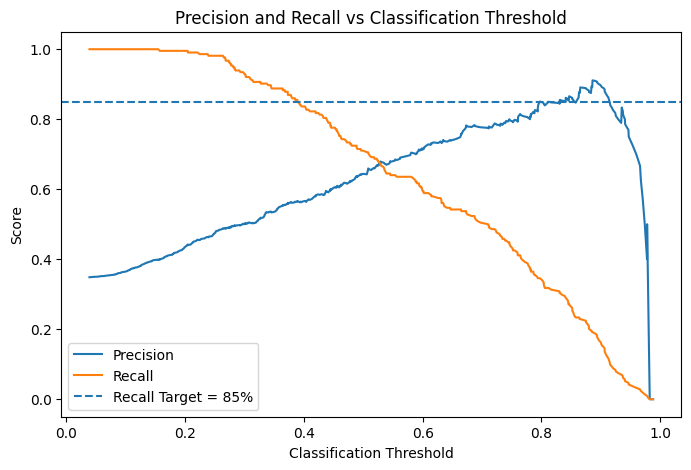

In [73]:
plt.figure(figsize=(8, 5))

plt.plot(
    oof_thresholds,
    oof_precision[:-1],
    label="Precision"
)

plt.plot(
    oof_thresholds,
    oof_recall[:-1],
    label="Recall"
)

plt.axhline(
    0.85,
    linestyle="--",
    label="Recall Target = 85%"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title("Precision and Recall vs Classification Threshold")

plt.legend()

plt.show()

In [74]:
tuned_test_pred = (
    y_test_prob >= tuned_threshold
).astype(int)

In [75]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_test_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_test_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_test_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_pred
)

In [76]:
print("Tuned Threshold:", round(tuned_threshold, 4))
print()
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))

Tuned Threshold: 0.3892

Accuracy : 0.7143
Precision: 0.5625
Recall   : 0.8333
F1 Score : 0.6716


In [77]:
default_cm = confusion_matrix(
    y_test,
    y_test_pred
)

tuned_cm = confusion_matrix(
    y_test,
    tuned_test_pred
)

default_tn, default_fp, default_fn, default_tp = default_cm.ravel()
tuned_tn, tuned_fp, tuned_fn, tuned_tp = tuned_cm.ravel()

In [78]:
threshold_comparison = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Negatives"
    ],

    "Default 0.50": [
        0.50,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        default_fp,
        default_fn
    ],

    "Tuned Threshold": [
        tuned_threshold,
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_fp,
        tuned_fn
    ]
})

threshold_comparison

,Metric,Default 0.50,Tuned Threshold
0,Threshold,0.500000,0.389207
1,Accuracy,0.720779,0.714286
2,Precision,0.590164,0.562500
3,Recall,0.666667,0.833333
4,F1 Score,0.626087,0.671642
5,False Positives,25.000000,35.000000
6,False Negatives,18.000000,9.000000


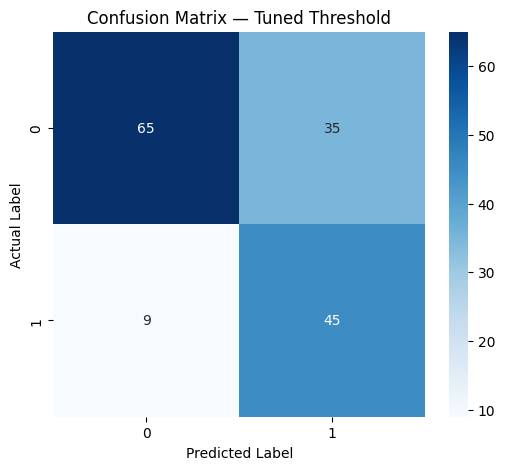

In [79]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix — Tuned Threshold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Phase 8 — Threshold Tuning Interpretation

The default threshold of 0.50 is changed to a lower threshold when necessary to prioritize recall.

A lower threshold generally causes the model to classify more patients as potentially diabetic.

This can:

- Increase recall.
- Reduce false negatives.
- Increase false positives.
- Reduce precision.

For a screening application, this trade-off can be reasonable because missing a potentially diabetic patient is more concerning than generating an additional screening referral.

The threshold was selected using out-of-fold predictions from the training data, so the test set remained untouched during threshold selection.

# Phase 9 — Feature Importance and Final Conclusion

In this phase, we identify which features are most useful to the final model.

Permutation importance is used because it can evaluate the importance of the complete modeling pipeline.

The features are ranked according to how much the model's ROC-AUC changes when a feature is randomly shuffled.

In [80]:
permutation_result = permutation_importance(
    final_model,
    X_train,
    y_train,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [81]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance Mean": permutation_result.importances_mean,
    "Importance Std": permutation_result.importances_std
})

importance_df = importance_df.sort_values(
    "Importance Mean",
    ascending=False
)

importance_df

,Feature,Importance Mean,Importance Std
1,Glucose,0.062812,0.010101
8,Glucose_BMI,0.035374,0.007601
0,Pregnancies,0.010869,0.003097
6,DiabetesPedigreeFunction,0.010419,0.002066
5,BMI,0.009604,0.004193
9,Glucose_Age,0.004259,0.002430
10,BMI_Age,0.002731,0.001795
7,Age,0.000301,0.000476
2,BloodPressure,0.000138,0.000294
4,Insulin,0.000063,0.000840


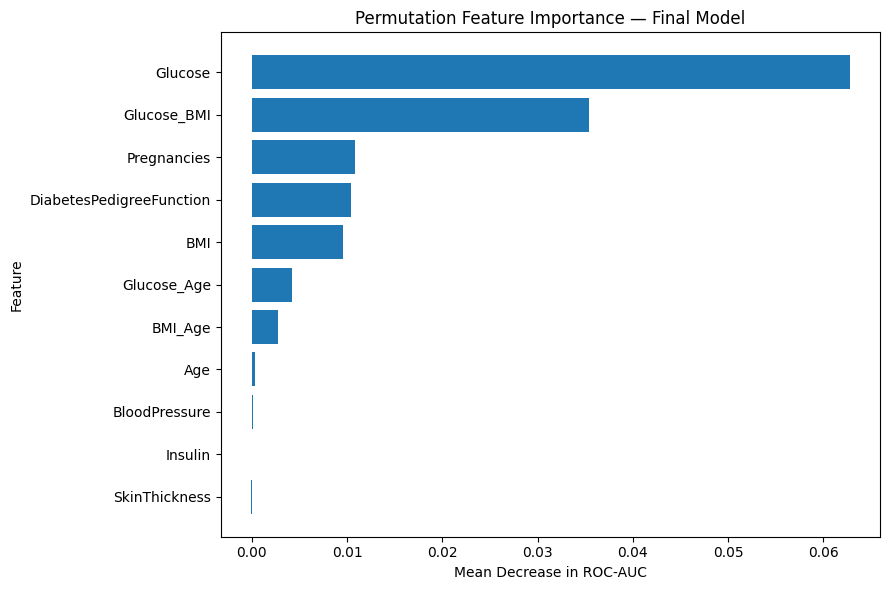

In [82]:
plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance Mean"]
)

plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")

plt.title("Permutation Feature Importance — Final Model")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [83]:
importance_df.head(5)

,Feature,Importance Mean,Importance Std
1,Glucose,0.062812,0.010101
8,Glucose_BMI,0.035374,0.007601
0,Pregnancies,0.010869,0.003097
6,DiabetesPedigreeFunction,0.010419,0.002066
5,BMI,0.009604,0.004193


# Final Project Summary

## Problem

SugarSense is a supervised machine learning project for early diabetes risk screening using clinical measurements.

## Dataset

The project uses the Pima Indians Diabetes Dataset containing 768 patient records and eight clinical input variables.

## Data Preparation

Problematic zero values in clinical measurements were treated as missing values.

Missing values were handled inside machine learning pipelines using median imputation.

Three row-wise interaction features were created:

- Glucose_BMI
- Glucose_Age
- BMI_Age

## Machine Learning Models

Six models were compared:

1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. XGBoost
6. SVM

The models were evaluated using 5-fold Stratified Cross-Validation.

## Hyperparameter Tuning

Logistic Regression, Random Forest, and XGBoost were tuned using RandomizedSearchCV with ROC-AUC as the scoring metric.

The final model was selected using cross-validation performance without using the test set for model selection.

## Final Evaluation

The selected model was evaluated on the untouched test set using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

A confusion matrix, ROC curve, and Precision-Recall curve were also generated.

## Threshold Tuning

The classification threshold was tuned using out-of-fold predictions from the training data.

The goal was to achieve a recall of at least 85% while maintaining the best possible precision among eligible thresholds.

The tuned threshold was then evaluated on the untouched test set.

## Feature Importance

Permutation importance was used to identify the features that contributed most to the final model's ROC-AUC.

## Limitations

The dataset contains only 768 patients and represents a specific population.

Some clinical measurements contain physiologically implausible zero values that were treated as missing.

The model may not generalize to all populations or clinical settings.

## Conclusion

SugarSense demonstrates how supervised machine learning can be used for early diabetes risk screening.

Because this is a screening model, recall is especially important because false negatives may represent potentially diabetic patients who are not flagged.

This project is for educational and screening-support purposes only and should not be used as a replacement for professional medical diagnosis.

In [84]:
print("=" * 60)
print("SUGARSENSE — FINAL PROJECT RESULTS")
print("=" * 60)

print("Final Model:", final_model_name)

print("\nTest Results at Default Threshold 0.50")
print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall   :", round(test_recall, 4))
print("F1 Score :", round(test_f1, 4))
print("ROC-AUC  :", round(test_roc_auc, 4))

print("\nThreshold Tuning")
print("Selected Threshold:", round(tuned_threshold, 4))
print("Tuned Accuracy :", round(tuned_accuracy, 4))
print("Tuned Precision:", round(tuned_precision, 4))
print("Tuned Recall   :", round(tuned_recall, 4))
print("Tuned F1 Score :", round(tuned_f1, 4))

print("\nConfusion Matrix — Tuned Threshold")
print("True Negatives :", tuned_tn)
print("False Positives:", tuned_fp)
print("False Negatives:", tuned_fn)
print("True Positives :", tuned_tp)

print("=" * 60)

SUGARSENSE — FINAL PROJECT RESULTS
Final Model: Tuned Logistic Regression

Test Results at Default Threshold 0.50
Accuracy : 0.7208
Precision: 0.5902
Recall   : 0.6667
F1 Score : 0.6261
ROC-AUC  : 0.8074

Threshold Tuning
Selected Threshold: 0.3892
Tuned Accuracy : 0.7143
Tuned Precision: 0.5625
Tuned Recall   : 0.8333
Tuned F1 Score : 0.6716

Confusion Matrix — Tuned Threshold
True Negatives : 65
False Positives: 35
False Negatives: 9
True Positives : 45


In [85]:
from sklearn.metrics import confusion_matrix

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [87]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Koneti sai charanya\OneDrive\Desktop\SugarSense\diabetes_screening_data.csv")

In [88]:
%whos

Variable                  Type                  Data/Info
---------------------------------------------------------
DecisionTreeClassifier    ABCMeta               <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
KNeighborsClassifier      ABCMeta               <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LogisticRegression        type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
Pipeline                  ABCMeta               <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier    ABCMeta               <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
RandomizedSearchCV        ABCMeta               <class 'sklearn.model_sel<...>arch.RandomizedSearchCV'>
SVC                       ABCMeta               <class 'sklearn.svm._classes.SVC'>
SimpleImputer             type                  <class 'sklearn.impute._base.SimpleImputer'>
StandardScaler            type                  <class 'sklearn.preproces<...>ng._data.StandardScaler'>


In [89]:
print(df.shape)
print(df.columns.tolist())

(768, 9)
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [90]:
print("Default threshold confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nTuned threshold confusion matrix:")
print(confusion_matrix(y_test, tuned_test_pred))

Default threshold confusion matrix:
[[75 25]
 [18 36]]

Tuned threshold confusion matrix:
[[65 35]
 [ 9 45]]


# Bonus 3 — Saving the Model with Joblib

The final fitted machine learning pipeline is saved so that it can be reused in a separate application.

The selected classification threshold is saved with the model.

In [91]:
import joblib
from pathlib import Path

Path("artifacts").mkdir(exist_ok=True)

joblib.dump(
    {
        "model": final_model,
        "threshold": float(tuned_threshold),
        "features": list(X_train.columns)
    },
    "artifacts/sugarsense_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


# Bonus 1 — Linear Regression

Linear Regression is used here as a separate regression exercise.

The model predicts the Glucose measurement from the other clinical features. Performance is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

This exercise is separate from the main diabetes classification task.

In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

regression_df = df.copy()

regression_features = [
    "Pregnancies",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

regression_X = regression_df[regression_features].replace(
    0, np.nan
)

regression_y = regression_df["Glucose"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    regression_X,
    regression_y,
    test_size=0.20,
    random_state=42
)

regression_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

regression_predictions = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, regression_predictions)
rmse = np.sqrt(mean_squared_error(y_reg_test, regression_predictions))

print("Linear Regression Results")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

Linear Regression Results
MAE: 22.265
RMSE: 27.785


# Bonus 2 — Learning Curve

A learning curve compares training performance with cross-validation performance at different training-set sizes.

It helps us understand whether the selected classifier may be overfitting or underfitting.

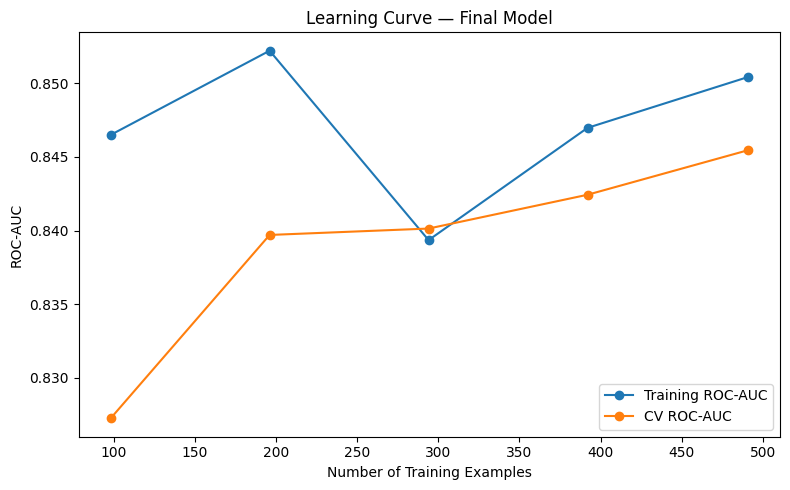

In [93]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, validation_scores = learning_curve(
    final_candidates[final_model_name],
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, marker="o", label="Training ROC-AUC")
plt.plot(train_sizes, validation_mean, marker="o", label="CV ROC-AUC")

plt.xlabel("Number of Training Examples")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve — Final Model")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
%whos

Variable                Type        Data/Info
---------------------------------------------
classification_report   function    <function classification_<...>rt at 0x000001B37B6F2020>
train_test_split        function    <function train_test_split at 0x000001B37B7EE0C0>


In [9]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Koneti sai charanya\OneDrive\Desktop\SugarSense\diabetes_screening_data.csv")
df.head()
print(df.shape)
print(df.columns.tolist())
print(df.head())

(768, 9)
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [10]:
import pandas as pd

df = pd.read_csv("diabetes_screening_data.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Dataset shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv("diabetes_screening_data.csv")

# Separate input features and target
X = df.drop(columns=["Outcome"]).copy()
y = df["Outcome"].copy()

# Replace invalid zero values, matching the app
zero_columns = [
    "Glucose", "BloodPressure",
    "SkinThickness", "Insulin", "BMI"
]
X[zero_columns] = X[zero_columns].replace(0, np.nan)

# Create the same engineered features as the app
X["Glucose_BMI"] = X["Glucose"] * X["BMI"]
X["Glucose_Age"] = X["Glucose"] * X["Age"]
X["BMI_Age"] = X["BMI"] * X["Age"]

# Load the existing saved model artifact
import joblib

artifact = joblib.load("artifacts/sugarsense_model.joblib")
model = artifact["model"]
threshold = artifact["threshold"]
feature_names = artifact["features"]

# Match the model's expected feature order
X = X.reindex(columns=feature_names)

# Recreate the test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Evaluate the saved model
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= threshold).astype(int)

print("Saved model threshold:", threshold)
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Saved model threshold: 0.3892071698226858

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.65      0.75       100
           1       0.56      0.83      0.67        54

    accuracy                           0.71       154
   macro avg       0.72      0.74      0.71       154
weighted avg       0.77      0.71      0.72       154

Confusion Matrix:
[[65 35]
 [ 9 45]]


In [12]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")

ROC-AUC Score: 0.8074
PR-AUC Score: 0.6525


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SugarSense — ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SugarSense — Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<Figure size 700x500 with 1 Axes>

<Figure size 700x500 with 1 Axes>

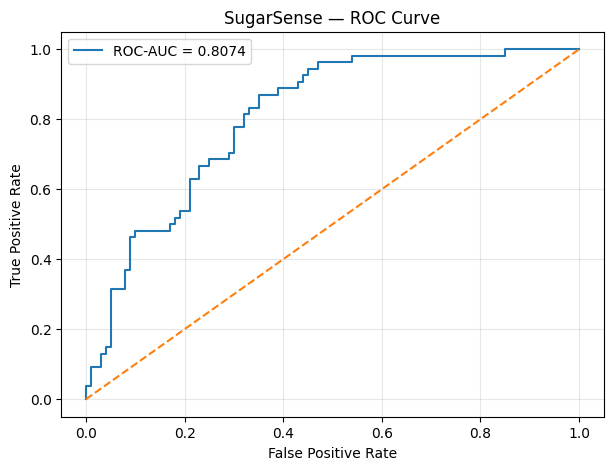

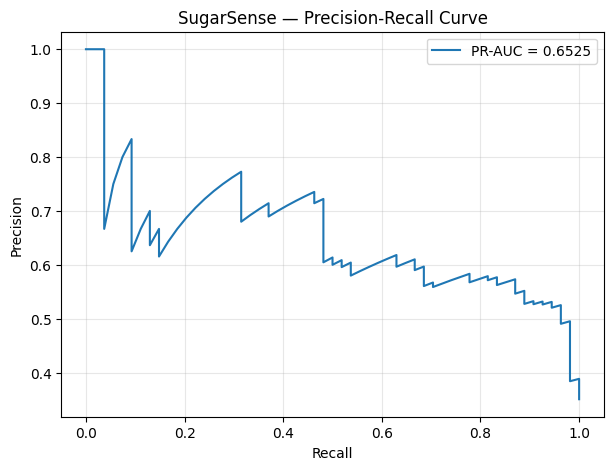

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SugarSense — ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SugarSense — Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()